<a href="https://colab.research.google.com/github/camilanurahma/MACHINE-LEARNING/blob/main/2304010030_Tugas_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LATAR BELAKANG**

Di era digital saat ini, media sosial sudah menjadi bagian penting dari kehidupan sehari-hari dan digunakan oleh berbagai kelompok usia. Namun, penggunaan media sosial yang berlebihan dapat memengaruhi fokus, waktu tidur, dan produktivitas. Dalam upaya untuk memahami pengaruh penggunaan media sosial terhadap produktivitas, dilakukan analisis terhadap data individu yang berkaitan dengan kebiasaan penggunaan media sosial, aktivitas digital harian, tingkat fokus, kualitas tidur, serta tingkat kecanduan media sosial.

# **PERNYATAAN MASALAH**

Penggunaan media sosial yang semakin tinggi telah menjadi bagian dari kehidupan sehari-hari dan dapat memberikan dampak yang berbeda terhadap produktivitas setiap individu. Oleh karena itu, diperlukan analisis untuk memahami pola penggunaan media sosial dan pengaruhnya terhadap aktivitas sehari-hari. Sebagai seorang data analyst, kita akan mencoba menjawab beberapa permasalahan berikut:

a. Bagaimana pola penggunaan media sosial berdasarkan karakteristik dan kebiasaan digital individu?

b. Bagaimana pengaruh aktivitas digital harian terhadap fokus dan kualitas tidur individu?

c. Bagaimana tingkat kecanduan media sosial memengaruhi produktivitas seseorang?

# **DATA**

Sebelum melakukan analisis, langkah pertama yang dilakukan adalah memanggil atau mengekspor dataset

In [221]:
import pandas as pd

df = pd.read_csv('/content/social_media_productivity_6000.csv')
df

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09
...,...,...,...,...,...,...,...,...,...
5995,20.0,2.05,0.71,7.92,4.13,48.0,100.00,Low,84.55
5996,28.0,6.28,4.90,4.07,5.64,198.0,99.52,Medium,37.63
5997,19.0,3.97,3.40,0.93,6.10,183.0,98.65,Medium,6.67
5998,30.0,11.11,9.16,3.76,6.43,179.0,79.82,High,0.00


Dataset ini merupakan data yang menggambarkan hubungan antara penggunaan media sosial dan tingkat produktivitas individu. Dataset ini mencakup informasi mengenai kebiasaan penggunaan media sosial, aktivitas digital harian, pola tidur, tingkat fokus, serta tingkat kecanduan media sosial.

Melalui dataset ini, dapat dilakukan analisis untuk memahami bagaimana penggunaan media sosial memengaruhi produktivitas individu. Selain itu, data juga dapat digunakan untuk melihat hubungan antara durasi penggunaan media sosial, waktu belajar atau bekerja, jumlah notifikasi, tingkat fokus, kualitas tidur, serta tingkat kecanduan media sosial terhadap produktivitas.

Berikut adalah variabel-variabel yang terdapat dalam dataset.

**Personal Information**

age: Usia individu.

**Digital Activity**

daily_screen_time: Total waktu layar per hari dalam jam.

social_media_hours: Total waktu yang dihabiskan di media sosial dalam jam

notifications_per_day: Jumlah notifikasi yang diterima setiap hari.

**Lifestyle**

study_hours: Total waktu belajar atau bekerja produktif dalam sehari

sleep_hours: Durasi tidur harian dalam jam.

**Mental Condition**

focus_score: Skor fokus mental individu dengan rentang 0–100.

addiction_level: Tingkat kecanduan media sosial dengan kategori rendah, sedang, atau tinggi.

**Productivity**

productivity_score: Skor produktivitas individu dengan rentang 0–100.

### **Menampilkan informasi lengkap dataset**

Setelah dataset berhasil dipanggil, untuk mengetahui gambaran umum dataset digunakan df.info(). Output ini menampilkan jumlah data, nama kolom, tipe data setiap variabel, serta jumlah data yang kosong pada masing-masing kolom.

In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB


Dataset memiliki 6000 baris dan 9 kolom, 8 diantaranya bertipe numerik dan 1 variabel (addiction_level) bertipe kategorial. Setiap kolom memiliki 5880 data terisi dari total 6000 data. Artinya, terdapat 120 data kosong pada masing-masing kolom.

# **CLEANING DATA**

### **Cek Missing Value**

Pengecekan missing value dilakukan untuk mengetahui jumlah data kosong pada setiap kolom.

In [223]:
df.isnull().sum()

,0
age,120
daily_screen_time,120
social_media_hours,120
study_hours,120
sleep_hours,120
notifications_per_day,120
focus_score,120
addiction_level,120
productivity_score,120


In [224]:
total_missing = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"Persentase total missing value pada dataset: {total_missing:.2f}%")

Persentase total missing value pada dataset: 2.00%


Seluruh variabel pada dataset memiliki 120 data kosong dari total 6000 data. Jumlah missing value tersebut setara dengan sekitar 2% dari total data, yang dapat ditangani dengan imputasi atau menghapus baris yang memiliki missing value.

### **Cek Normalitas Data Numerik**

Pengecekan normalitas dilakukan untuk melihat distribusi data pada setiap variabel numerik. Hasil uji normalitas akan digunakan untuk menentukan metode imputasi yang tepat, yaitu menggunakan mean jika data berdistribusi normal dan median jika data tidak normal.

In [225]:
from scipy.stats import shapiro

numeric_cols = [
    'age',
    'daily_screen_time',
    'social_media_hours',
    'study_hours',
    'sleep_hours',
    'notifications_per_day',
    'focus_score',
    'productivity_score'
]

for col in numeric_cols:
    stat, p = shapiro(df[col].dropna())

    print(f'Kolom: {col}')
    print(f'P-value: {p:.4f}')

    if p > 0.05:
        print('Distribusi normal')
    else:
        print('Distribusi tidak normal')

    print('---------------------')

Kolom: age
P-value: 0.0000
Distribusi tidak normal
---------------------
Kolom: daily_screen_time
P-value: 0.0000
Distribusi tidak normal
---------------------
Kolom: social_media_hours
P-value: 0.0000
Distribusi tidak normal
---------------------
Kolom: study_hours
P-value: 0.0000
Distribusi tidak normal
---------------------
Kolom: sleep_hours
P-value: 0.0000
Distribusi tidak normal
---------------------
Kolom: notifications_per_day
P-value: 0.0000
Distribusi tidak normal
---------------------
Kolom: focus_score
P-value: 0.0000
Distribusi tidak normal
---------------------
Kolom: productivity_score
P-value: 0.0000
Distribusi tidak normal
---------------------


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5880.
  res = hypotest_fun_out(*samples, **kwds)


Hasil uji normalitas Shapiro-Wilk menunjukkan bahwa seluruh kolom numerik memiliki p-value kurang dari 0,05. Artinya, data tidak berdistribusi normal, sehingga missing value pada kolom numerik akan diisi menggunakan median.

### **Perbaikan Data Missing**

Perbaikan missing value dilakukan sesuai dengan tipe data pada setiap variabel, dibagi ke dalam dua bagian yaitu data numerik dan data kategorikal.

**Data Numerik**

Karena data berdistribusi tidak normal, maka metode imputasi yang digunakan adalah median

In [226]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

**Data Kategori**

Karena addiction_level merupakan data kategorikal, missing value diisi menggunakan modus. Modus dipilih karena merupakan nilai yang paling sering muncul sehingga dianggap paling mewakili kategori pada data tersebut.

In [227]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

### **Cek Data Duplikat**

Pengecekan data duplikat dilakukan untuk memastikan tidak ada baris data yang tercatat lebih dari satu kali karena dapat memengaruhi hasil analisis

In [228]:
df.duplicated().sum()

np.int64(0)

Nilai data duplikat adalah 0, sehingga tidak terdapat baris data yang tercatat lebih dari satu kali. Sehingga tidak diperlukan penghapusan data duplikat

### **Cek Inkonsistensi**

Pengecekan inkonsistensi data dilakukan untuk memastikan bahwa setiap nilai pada dataset masih berada dalam rentang yang wajar dan sesuai dengan logika. Proses ini penting agar tidak ada data yang tidak masuk akal, seperti waktu penggunaan perangkat digital lebih dari 24 jam atau durasi media sosial yang lebih besar dari total waktu penggunaan perangkat digital per hari.

In [229]:
# 1. Cek nilai social_media_hours yang lebih besar dari daily_screen_time
inkonsistensi_screen_time = df[df['social_media_hours'] > df['daily_screen_time']]

# 2. Cek nilai daily_screen_time yang lebih dari 24 jam atau kurang dari 0
inkonsistensi_daily_screen = df[(df['daily_screen_time'] > 24) | (df['daily_screen_time'] < 0)]

# 3. Cek nilai study_hours yang lebih dari 24 jam atau kurang dari 0
inkonsistensi_study = df[(df['study_hours'] > 24) | (df['study_hours'] < 0)]

# 4. Cek nilai sleep_hours yang lebih dari 24 jam atau kurang dari 0
inkonsistensi_sleep = df[(df['sleep_hours'] > 24) | (df['sleep_hours'] < 0)]

# 5. Cek nilai focus_score di luar rentang 0–100
inkonsistensi_focus = df[(df['focus_score'] < 0) | (df['focus_score'] > 100)]

# 6. Cek nilai productivity_score di luar rentang 0–100
inkonsistensi_productivity = df[(df['productivity_score'] < 0) | (df['productivity_score'] > 100)]

# 7. Cek nilai addiction_level yang tidak sesuai kategori
kategori_valid = ['Low', 'Medium', 'High']
inkonsistensi_addiction = df[~df['addiction_level'].isin(kategori_valid)]

# Tampilkan jumlah inkonsistensi
print("Jumlah social_media_hours > daily_screen_time :", len(inkonsistensi_screen_time))
print("Jumlah daily_screen_time tidak valid :", len(inkonsistensi_daily_screen))
print("Jumlah study_hours tidak valid :", len(inkonsistensi_study))
print("Jumlah sleep_hours tidak valid :", len(inkonsistensi_sleep))
print("Jumlah focus_score tidak valid :", len(inkonsistensi_focus))
print("Jumlah productivity_score tidak valid :", len(inkonsistensi_productivity))
print("Jumlah addiction_level tidak valid :", len(inkonsistensi_addiction))

Jumlah social_media_hours > daily_screen_time : 29
Jumlah daily_screen_time tidak valid : 0
Jumlah study_hours tidak valid : 0
Jumlah sleep_hours tidak valid : 0
Jumlah focus_score tidak valid : 0
Jumlah productivity_score tidak valid : 0
Jumlah addiction_level tidak valid : 0


Terdapat 29 data yang memiliki nilai social_media_hours lebih besar dari daily_screen_time. Kondisi ini tidak logis karena waktu penggunaan media sosial seharusnya tidak melebihi total waktu penggunaan perangkat digital perhari.

Sementara itu, tidak ditemukan inkonsistensi pada variabel lain seperti daily_screen_time, study_hours, sleep_hours, focus_score, productivity_score, dan addiction_level

### **Menangani Inkonsistensi**

In [230]:
df = df[df['social_media_hours'] <= df['daily_screen_time']]

Data invalid pada nilai social_media_hours yang lebih besar dari daily_screen_time dihapus dari dataset, sebagai upaya menangani inkonsistensi kecil

### **Menambahkan Kolom Baru**

Penambahan kolom baru dilakukan untuk mempermudah analisis. Kolom screen_time_ratio digunakan untuk melihat proporsi waktu  yang digunakan untuk media sosial.

In [231]:
df['screen_time_ratio'] = df['social_media_hours'] / df['daily_screen_time']
df[['social_media_hours', 'daily_screen_time', 'screen_time_ratio']].head()

/tmp/ipykernel_10560/1180019323.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['screen_time_ratio'] = df['social_media_hours'] / df['daily_screen_time']


,social_media_hours,daily_screen_time,screen_time_ratio
0,2.81,5.95,0.472269
1,2.33,3.82,0.609948
2,1.64,3.57,0.459384
3,4.37,10.27,0.425511
4,1.60,2.42,0.661157


### **Data Hasil Preprocessing**

Data di bawah ini merupakan dataset yang sudah melewati tahap preprocessing, seperti penanganan missing value, pengecekan data duplikat, pengecekan inkonsistensi, serta penambahan beberapa kolom baru. Dataset ini sudah lebih bersih dan siap digunakan untuk proses analisis serta visualisasi data.

In [232]:
df

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score,screen_time_ratio
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49,0.472269
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54,0.609948
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52,0.459384
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82,0.425511
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09,0.661157
...,...,...,...,...,...,...,...,...,...,...
5995,20.0,2.05,0.71,7.92,4.13,48.0,100.00,Low,84.55,0.346341
5996,28.0,6.28,4.90,4.07,5.64,198.0,99.52,Medium,37.63,0.780255
5997,19.0,3.97,3.40,0.93,6.10,183.0,98.65,Medium,6.67,0.856423
5998,30.0,11.11,9.16,3.76,6.43,179.0,79.82,High,0.00,0.824482


In [233]:
df.to_csv('data_medsos3.csv', index=False)

# **ANALISIS DATA**

### **1. Pola Penggunaan Media Sosial Berdasarkan Karakteristik dan Kebiasaan Digital Individu**

Analisis pola penggunaan media sosial berdasarkan karakteristik dan kebiasaan digital individu dilakukan untuk melihat bagaimana usia, waktu layar harian, durasi penggunaan media sosial, jumlah notifikasi, dan tingkat kecanduan dapat menggambarkan perilaku digital seseorang. Melalui analisis ini, dapat diketahui pola penggunaan media sosial yang paling sering terjadi serta faktor-faktor yang berhubungan dengan tingginya penggunaan media sosial pada individu.

### **BERDASARKAN USIA**

Analisis pola penggunaan media sosial berdasarkan usia dilakukan untuk melihat apakah terdapat perbedaan kebiasaan digital pada setiap kelompok usia. Usia dapat memengaruhi durasi penggunaan media sosial maupun tingkat kecanduan digital seseorang. Melalui analisis ini, dapat diketahui kelompok usia mana yang paling sering menggunakan media sosial dan kelompok usia mana yang memiliki tingkat kecanduan lebih tinggi.

Berikut adalah masalah yang dapat dijawab melalui analisis ini:

a. Kelompok usia mana yang memiliki durasi penggunaan media sosial paling tinggi?

b. Apakah kelompok usia tertentu memiliki tingkat kecanduan media sosial yang lebih tinggi?

**Membuat Kelompok Usia**

Kelompok usia dibuat agar analisis lebih mudah dilakukan dan perbedaan pola penggunaan media sosial pada setiap rentang usia dapat terlihat dengan lebih jelas. Kelompok usia dibuat menggunakan rentang interval dari usia minimum dan maksimum pada dataset, sehingga pembagian kelompok lebih teratur dan sesuai dengan sebaran data yang ada.

In [234]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41],
    labels=[
        '15-16', '17-18', '19-20', '21-22',
        '23-24', '25-26', '27-28', '29-30',
        '31-32', '33-34', '35-36', '37-38', '39-40'
    ],
    right=False
)

/tmp/ipykernel_10560/4046382611.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_group'] = pd.cut(


Dari hasil perhitungan pembangian kelompok, diperoleh 13 kelas usia sehingga rentang usia dibagi menjadi beberapa kelompok dengan interval yang relatif seimbang

**Rata-Rata Durasi Penggunaan Media Sosial Pada Setiap Kelompok Usia**

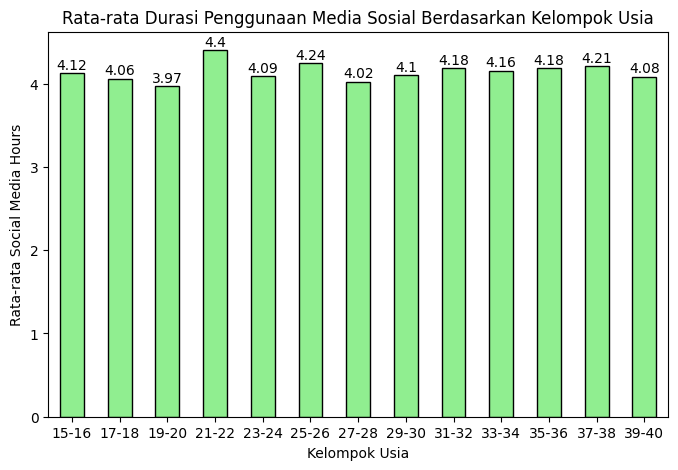

In [235]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

ax = avg_social_media.plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title('Rata-rata Durasi Penggunaan Media Sosial Berdasarkan Kelompok Usia')
plt.xlabel('Kelompok Usia')
plt.ylabel('Rata-rata Social Media Hours')

# Membuat label sumbu x tetap lurus
plt.xticks(rotation=0)

# Menambahkan angka di atas bar
for i, v in enumerate(avg_social_media):
    plt.text(i, v + 0.05, round(v, 2), ha='center')

plt.show()

Kelompok usia 21–22 tahun memiliki rata-rata durasi penggunaan media sosial paling tinggi, yaitu sekitar 4,4 jam per hari. Sementara itu, kelompok usia 19–20 tahun memiliki rata-rata durasi penggunaan media sosial paling rendah, yaitu sekitar 3,97 jam per hari.

Secara keseluruhan, rata-rata durasi penggunaan media sosial pada setiap kelompok usia tidak jauh berbeda yaitu pada rentang 4 jam per hari.

**Distribusi Addiction Level Per Kelompok Usia**

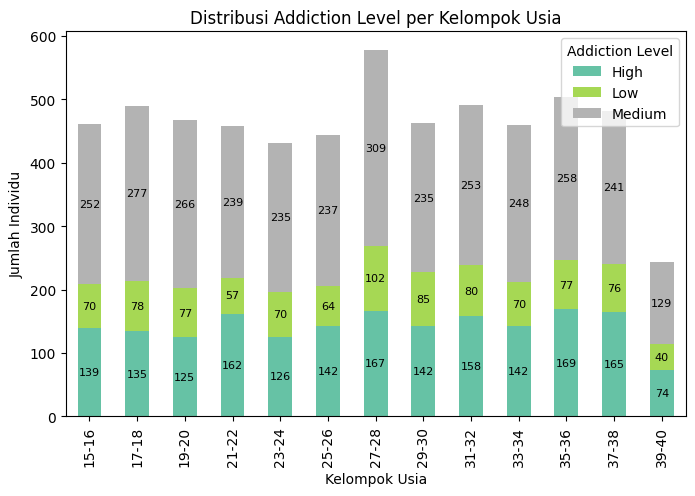

In [236]:
import matplotlib.pyplot as plt
ax = usia_addiction.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set2')

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=8)

plt.title('Distribusi Addiction Level per Kelompok Usia')
plt.xlabel('Kelompok Usia')
plt.ylabel('Jumlah Individu')
plt.legend(title='Addiction Level')
plt.show()

Kategori addiction level yang paling banyak muncul pada seluruh kelompok usia adalah Medium. Sementara itu, kategori Low memiliki jumlah paling sedikit pada hampir semua kelompok usia. Kelompok usia 35–36 tahun memiliki addiction level High yang lebih tinggi daripada kelompok usia lainnya, yaitu sebanyak 169 individu. Setelah itu, kelompok usia 27–28 tahun dan 37–38 tahun juga memiliki jumlah addiction level High yang cukup tinggi, masing-masing sebanyak 167 dan 165 individu.

### **BERDASARKAN DAILY SCREEN TIME**

Analisis pola penggunaan media sosial berdasarkan total waktu penggunaan perangkat digital per hari dilakukan untuk melihat apakah durasi penggunaan perangkat yang tinggi dapat memengaruhi produktivitas dan waktu belajar atau bekerja seseorang. Semakin lama individu menggunakan perangkat digital, semakin besar kemungkinan waktu untuk aktivitas produktif menjadi berkurang. Melalui analisis ini, dapat diketahui apakah durasi penggunaan perangkat digital yang tinggi berhubungan dengan produktivitas yang lebih rendah dan study hours yang lebih sedikit.

Berikut adalah masalah yang dapat dijawab melalui analisis ini:

a. Apakah individu dengan waktu layar lebih tinggi cenderung memiliki produktivitas lebih rendah?

b. Bagaimana hubungan antara waktu layar harian dengan waktu belajar atau bekerja (study_hours)?


**Kelompok Total Waktu Penggunaan Perangkat Digital Per Hari**

Pengelompokan total waktu penggunaan perangkatt digital per hari dilakukan agar data lebih mudah dianalisis dan dibandingkan antar kelompok. Dengan membaginya ke dalam beberapa kategori, hubungan antara screen time, produktivitas, dan study hours dapat terlihat dengan lebih jelas.

In [237]:
df['screen_time_group'] = pd.cut(
    df['daily_screen_time'],
    bins=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    labels=[
        '2-2.99', '3-3.99', '4-4.99', '5-5.99', '6-6.99',
        '7-7.99', '8-8.99', '9-9.99', '10-10.99', '11-11.99'
    ],
    right=False
)

/tmp/ipykernel_10560/1744319404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['screen_time_group'] = pd.cut(


Pengelompokan dilakukan dengan cara menghitung jumlah kelas dan rentang interval data. Awalnya jumlah kategori waktu layar harian dibuat sebanyak 14 kelas mengikuti hasil perhitungan jumlah kelas data. Namun, rentang pada setiap kelas menjadi terlalu kecil sehingga perbedaan antar kategori sulit terlihat. Oleh karena itu, kategori waktu layar disederhanakan menjadi 10 kelompok.

**Rata-Rata Productivity Score Pada Setiap Kategori Waktu Penggunaan Perangkat Digital Per Hari**

In [238]:
screen_productivity = df.groupby('screen_time_group')['productivity_score'].mean().reset_index()
screen_productivity

/tmp/ipykernel_10560/754504758.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  screen_productivity = df.groupby('screen_time_group')['productivity_score'].mean().reset_index()


,screen_time_group,productivity_score
0,2-2.99,54.915559
1,3-3.99,51.458855
2,4-4.99,47.490425
3,5-5.99,44.056623
4,6-6.99,39.034106
5,7-7.99,33.049147
6,8-8.99,30.559554
7,9-9.99,27.999242
8,10-10.99,23.789965
9,11-11.99,21.302632


Rata-rata productivity score terus menurun seiring meningkatnya waktu penggunaan perangkat digital per hari. Individu dengan screen time 2–2,99 jam memiliki rata-rata productivity score tertinggi, yaitu sekitar 54,92, sedangkan individu dengan screen time 11–11,99 jam memiliki rata-rata productivity score terendah, yaitu sekitar 21,30.

Hasil ini menunjukkan bahwa semakin tinggi waktu layar harian, produktivitas individu cenderung semakin rendah.

**Korelasi Daily Screen Time dan Study Hours**

In [239]:
korelasi_screen_study = df['daily_screen_time'].corr(df['study_hours'])
print('Korelasi daily_screen_time dan study_hours :', korelasi_screen_study)

Korelasi daily_screen_time dan study_hours : 0.0018719931600488851


Nilai korelasi antara daily_screen_time dan study_hours sebesar 0,0019 bersifat positif, berarti ketika durasi penggunaan perangkat digital meningkat, study hours juga cenderung meningkat

**BERDASARKAN DURASI PENGGUNAAN MEDIA SOSIAL**

Analisis pola penggunaan media sosial berdasarkan durasi penggunaan media sosial dilakukan untuk melihat seberapa besar media sosial mengambil porsi dari total waktu penggunaan perangkat digital individu. Durasi penggunaan media sosial juga dapat berhubungan dengan tingkat kecanduan serta waktu belajar atau bekerja seseorang. Melalui analisis ini, dapat diketahui apakah penggunaan media sosial yang lebih tinggi cenderung berkaitan dengan addiction level yang lebih tinggi dan study hours yang lebih rendah.

Berikut adalah masalah yang dapat dijawab melalui analisis ini:

a. Berapa proporsi waktu penggunaan perangkat digital yang digunakan khusus untuk media sosial?

b. Apakah individu dengan durasi penggunaan media sosial lebih tinggi memiliki tingkat kecanduan yang lebih tinggi?

c. Apakah individu dengan durasi penggunaan media sosial yang lebih tinggi memiliki `study_hours` yang lebih rendah?


**Rata-Rata Proporsi Penggunaan Media Sosial**

Kolom screen_time_ratio sudah dibuat pada tahap preprocessing untuk menunjukkan proporsi waktu penggunaan perangkat digital yang digunakan untuk media sosial. Pada tahap ini, analisis difokuskan pada rata-rata proporsi penggunaan media sosial untuk melihat seberapa besar waktu penggunaan perangkat digital yang dihabiskan untuk media sosial.

In [240]:
rata_rasio = df['screen_time_ratio'].mean()
print('Rata-rata proporsi penggunaan media sosial :', rata_rasio)

Rata-rata proporsi penggunaan media sosial : 0.5978346949023624


Rata-rata proporsi penggunaan media sosial sebesar 0,598 atau sekitar 59,8%. Artinya, hampir 60% dari total waktu penggunaan perangkat digital individu digunakan khusus untuk media sosial.

**Kategori Durasi Penggunaan Media Sosial**

In [241]:
df['social_media_duration_category'] = pd.cut(
    df['social_media_hours'],
    bins=[0.66, 1.66, 2.66, 3.66, 4.66, 5.66, 6.66, 7.66, 8.66, 9.66, 10.67],
    labels=[
        '0.66-1.65',
        '1.66-2.65',
        '2.66-3.65',
        '3.66-4.65',
        '4.66-5.65',
        '5.66-6.65',
        '6.66-7.65',
        '7.66-8.65',
        '8.66-9.65',
        '9.66-10.66'
    ],
    right=False
)

/tmp/ipykernel_10560/3083317283.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['social_media_duration_category'] = pd.cut(


Pengelompokan durasi penggunaan media sosial dilakukan dengan cara menghitung jumlah kelas dan rentang interval data. Awalnya, jumlah kelas yang diperoleh adalah 14 kelas, tetapi rentangnya terlalu kecil sehingga disederhanakan menjadi 10 kategori

**Distribusi Addiction Level Pada Setiap Kategori Durasi Penggunaan Media Sosial**

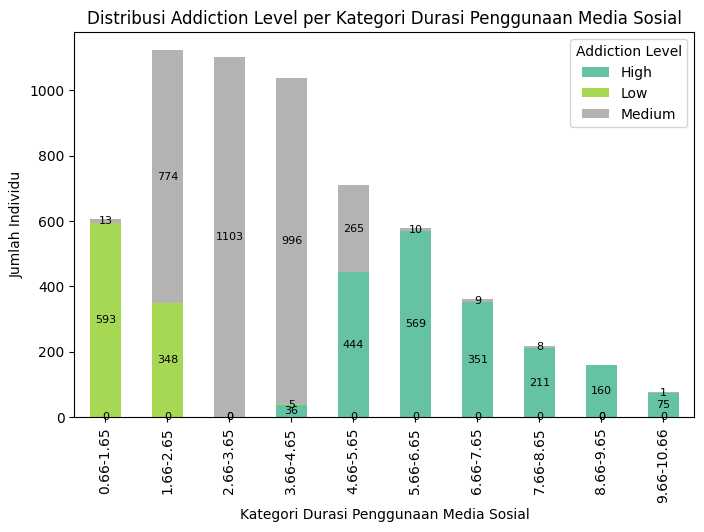

In [242]:
import matplotlib.pyplot as plt
ax = social_addiction.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set2')

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=8)

plt.title('Distribusi Addiction Level per Kategori Durasi Penggunaan Media Sosial')
plt.xlabel('Kategori Durasi Penggunaan Media Sosial')
plt.ylabel('Jumlah Individu')
plt.legend(title='Addiction Level')
plt.show()

Kategori durasi penggunaan media sosial 0,66–1,65 jam didominasi oleh addiction level Low, sedangkan kategori 1,66–4,65 jam lebih banyak didominasi oleh addiction level Medium. Pada kategori 4,66 jam ke atas, addiction level High menjadi kategori yang paling dominan.

Kategori durasi penggunaan media sosial 5,66–6,65 jam memiliki jumlah individu dengan addiction level High paling banyak, yaitu 569 orang. Hasil ini menunjukkan bahwa semakin tinggi durasi penggunaan media sosial, tingkat kecanduan media sosial juga cenderung semakin tinggi.

**Korelasi Social Media Hours dan Study Hours**

In [243]:
korelasi_social_study = df['social_media_hours'].corr(df['study_hours'])
print('Korelasi social_media_hours dan study_hours :', korelasi_social_study)

Korelasi social_media_hours dan study_hours : 0.0026088609554529756


Nilai korelasi yang positif menunjukkan bahwa ketika durasi penggunaan media sosial meningkat, study hours juga cenderung meningkat bukan malah menurun.

**BERDASARKAN JUMLAH NOTIFIKASI**

Analisis pola penggunaan media sosial berdasarkan jumlah notifikasi dilakukan untuk melihat apakah banyaknya notifikasi yang diterima dapat memengaruhi durasi penggunaan media sosial seseorang. Semakin banyak notifikasi yang diterima, semakin besar kemungkinan individu lebih sering membuka media sosial. Melalui analisis ini, dapat diketahui apakah jumlah notifikasi yang lebih tinggi berhubungan dengan durasi penggunaan media sosial yang lebih tinggi.

Berikut adalah masalah yang dapat dijawab melalui analisis ini:

a. Apakah jumlah notifikasi yang lebih tinggi berhubungan dengan durasi penggunaan media sosial yang lebih tinggi?

**Korelasi Notifications Per Day dan Social Media Hours**

In [244]:
korelasi_notif_social = df['notifications_per_day'].corr(df['social_media_hours'])
print('Korelasi notifications_per_day dan social_media_hours :', korelasi_notif_social)

Korelasi notifications_per_day dan social_media_hours : -0.012003122658192991


Nilai korelasi menunjukkan arah hubungan negatif, jadi ketika jumlah notifikasi meningkat, durasi penggunaan media sosial cenderung menurun.

**BERDASARKAN TINGKAT KECANDUAN**

Analisis pola penggunaan media sosial berdasarkan tingkat kecanduan dilakukan untuk melihat kategori addiction level yang paling banyak dimiliki individu serta perbedaan durasi penggunaan media sosial pada setiap kategori kecanduan. Tingkat kecanduan media sosial dapat menggambarkan seberapa besar media sosial menjadi bagian dari aktivitas digital sehari-hari. Melalui analisis ini, dapat diketahui kategori addiction level yang paling dominan dan apakah individu dengan addiction level lebih tinggi memiliki durasi penggunaan media sosial yang lebih besar.

Berikut adalah masalah yang dapat dijawab melalui analisis ini:

a. Kategori addiction level mana yang paling banyak dimiliki individu?

b. Bagaimana perbedaan rata-rata durasi penggunaan media sosial pada setiap kategori addiction level?

**Jumlah Individu Pada Setiap Kategori Addiction_level**

In [245]:
jumlah_addiction = df['addiction_level'].value_counts().reset_index()
jumlah_addiction.columns = ['addiction_level', 'jumlah_individu']
jumlah_addiction

,addiction_level,jumlah_individu
0,Medium,3179
1,High,1846
2,Low,946


Kategori addiction level yang paling banyak dimiliki individu adalah Medium, yaitu sebanyak 3179 orang. Kemudian untuk kategori High berjumlah 1846 orang dan kategori Low berjumlah 946 orang.

Hasil ini menunjukkan bahwa sebagian besar individu dalam dataset memiliki tingkat kecanduan media sosial pada kategori sedang.

**Rata-Rata Durasi Penggunaan Media Sosial Pada Setiap Kategori Addiction Level**

In [246]:
rata_social_addiction = df.groupby('addiction_level')['social_media_hours'].mean().reset_index()
rata_social_addiction

,addiction_level,social_media_hours
0,High,6.717069
1,Low,1.495840
2,Medium,3.415082


Individu dengan tingkat kecanduan tinggi memiliki rata-rata durasi penggunaan media sosial paling tinggi, yaitu sekitar 6,71 jam per hari. Sementara itu, individu dengan tingkat kecanduan sedang memiliki rata-rata durasi sekitar 3,41 jam per hari dan tingkat kecanduan rendah sekitar 1,49 jam per hari.

Hasil ini menunjukkan bahwa semakin tinggi tingkat kecanduan media sosial, durasi penggunaan media sosial juga cenderung semakin tinggi.

### **2. Pengaruh Aktivitas Digital Harian Terhadap Fokus dan Kualitas Tidur Individu**

Analisis pengaruh aktivitas digital harian terhadap fokus dan kualitas tidur dilakukan untuk melihat apakah penggunaan media sosial, waktu penggunaan perangkat digital, dan jumlah notifikasi dapat memengaruhi kondisi individu. Aktivitas digital yang terlalu tinggi dapat membuat individu lebih sulit fokus dan memiliki waktu tidur yang lebih sedikit. Melalui analisis ini, dapat diketahui apakah durasi penggunaan media sosial, waktu penggunaan perangkat digital, dan jumlah notifikasi memiliki hubungan dengan focus score dan sleep hours.

Berikut adalah masalah yang dapat dijawab melalui analisis ini:

a. Bagaimana hubungan antara durasi penggunaan media sosial (`social_media_hours`) dengan `focus_score`?

b. Bagaimana hubungan antara waktu penggunaan perangkat digital (`daily_screen_time`) dengan `sleep_hours`?

c. Apakah jumlah notifikasi (`notifications_per_day`) yang lebih tinggi berhubungan dengan `focus_score` yang lebih rendah?

**Korelasi Social Media Hours dan Focus Score**

In [247]:
korelasi_social_focus = df['social_media_hours'].corr(df['focus_score'])
print('Korelasi social_media_hours dan focus_score :', korelasi_social_focus)

Korelasi social_media_hours dan focus_score : -0.5797863726829057


Nilai korelasi sebesar -0,58 menunjukkan hubungan yang bersifat negatif antara durasi penggunaan media sosial dan focus score. Artinya, ketika durasi penggunaan media sosial meningkat, focus score cenderung menurun.

**Korelasi Daily Screen Time dan Sleep Hours**

In [248]:
korelasi_screen_sleep = df['daily_screen_time'].corr(df['sleep_hours'])
print('Korelasi daily_screen_time dan sleep_hours :', korelasi_screen_sleep)

Korelasi daily_screen_time dan sleep_hours : 0.0008774657583265932


Nilai korelasi sebesar 0,0009 menunjukkan hubungan yang bersifat positif antara waktu penggunaan perangkat digital dan sleep hours. Artinya, ketika waktu penggunaan perangkat digital meningkat, sleep hours juga cenderung meningkat.

**Korelasi Notifications Per Day dan Focus Score**

In [249]:
korelasi_notif_focus = df['notifications_per_day'].corr(df['focus_score'])
print('Korelasi notifications_per_day dan focus_score :', korelasi_notif_focus)

Korelasi notifications_per_day dan focus_score : -0.1787459032616296


Nilai korelasi sebesar -0,18 menunjukkan hubungan yang bersifat negatif antara jumlah notifikasi dan focus score. Artinya, ketika jumlah notifikasi meningkat, focus score cenderung menurun.

### **3. Pengaruh Tingkat Kecanduan Media Sosial terhadap Produktivitas Individu**

Analisis pengaruh tingkat kecanduan media sosial terhadap produktivitas dilakukan untuk melihat apakah individu dengan tingkat kecanduan yang berbeda memiliki produktivitas, focus score, dan study hours yang berbeda. Tingkat kecanduan media sosial yang tinggi dapat membuat individu lebih sulit fokus dan mengurangi waktu untuk belajar atau bekerja. Melalui analisis ini, dapat diketahui apakah individu dengan tingkat kecanduan yang lebih tinggi cenderung memiliki produktivitas yang lebih rendah.

Berikut adalah masalah yang dapat dijawab melalui analisis ini:

a. Bagaimana rata-rata `productivity_score` pada setiap kategori `addiction_level`?

b. Bagaimana perbedaan `focus_score` pada kategori addiction level Low, Medium, dan High?

c. Bagaimana rata-rata `study_hours` pada setiap kategori `addiction_level`?

**RATA-RATA PRODUCTIVITY SCORE PADA SETIAP KATEGORI ADDICTION LEVEL**

In [250]:
rata_productivity = df.groupby('addiction_level')['productivity_score'].mean().reset_index()
rata_productivity

,addiction_level,productivity_score
0,High,20.720796
1,Low,56.591247
2,Medium,41.734473


Individu dengan tingkat kecanduan tinggi memiliki rata-rata productivity score paling rendah, yaitu sekitar 20,72. Sementara itu, individu dengan tingkat kecanduan rendah memiliki rata-rata productivity score paling tinggi, yaitu sekitar 56,59.

Hasil ini menunjukkan bahwa semakin tinggi tingkat kecanduan media sosial, produktivitas individu cenderung semakin rendah.

**RATA-RATA FOCUS SCORE PADA SETIAP KATEGORI ADDICTION LEVEL**

In [251]:
rata_focus = df.groupby('addiction_level')['focus_score'].mean().reset_index()
rata_focus

,addiction_level,focus_score
0,High,91.006463
1,Low,99.796110
2,Medium,98.613677


Individu dengan tingkat kecanduan tinggi memiliki rata-rata focus score paling rendah, yaitu sekitar 91,01. Sementara itu, individu dengan tingkat kecanduan rendah memiliki rata-rata focus score paling tinggi, yaitu sekitar 99,80.

Hasil ini menunjukkan bahwa semakin tinggi tingkat kecanduan media sosial, focus score individu cenderung semakin rendah.

**RATA-RATA STUDY HOURS PADA SETIAP KATEGORI ADDICTION LEVEL**

In [252]:
rata_study = df.groupby('addiction_level')['study_hours'].mean().reset_index()
rata_study

,addiction_level,study_hours
0,High,4.074428
1,Low,4.143975
2,Medium,4.048509


Rata-rata study hours pada setiap kategori tingkat kecanduan tidak memiliki perbedaan yang terlalu besar. Seluruh kategori memiliki rata-rata study hours sekitar 4 jam per hari.

Individu dengan tingkat kecanduan rendah memiliki rata-rata study hours tertinggi, yaitu sekitar 4,14 jam. Sementara itu, individu dengan tingkat kecanduan sedang memiliki rata-rata study hours terendah, yaitu sekitar 4,048 jam.

Hasil ini menunjukkan bahwa tingkat kecanduan media sosial tetap memengaruhi study hours, meskipun tidak besar

# **KESIMPULAN**

Hasil analisis menunjukkan bahwa penggunaan media sosial yang tinggi cenderung berkaitan dengan tingkat kecanduan yang lebih tinggi, focus score yang lebih rendah, dan produktivitas yang lebih rendah. Kelompok usia 21–22 tahun memiliki rata-rata durasi penggunaan media sosial paling tinggi, sedangkan kelompok usia 35–36 tahun memiliki jumlah individu dengan tingkat kecanduan tinggi paling banyak. Durasi penggunaan perangkat digital yang lebih tinggi cenderung diikuti dengan productivity score yang lebih rendah, tetapi hampir tidak memiliki hubungan dengan study hours. Hampir 60% dari total waktu penggunaan perangkat digital digunakan khusus untuk media sosial. Semakin tinggi durasi penggunaan media sosial, tingkat kecanduan media sosial juga cenderung semakin tinggi, tetapi tidak memiliki hubungan yang kuat dengan study hours. Jumlah notifikasi juga hampir tidak memiliki hubungan dengan durasi penggunaan media sosial. Selain itu, kategori kecanduan pada level sedang menjadi kategori yang paling banyak dimiliki individu. Individu dengan tingkat kecanduan tinggi memiliki rata-rata durasi penggunaan media sosial paling tinggi, productivity score paling rendah, dan focus score paling rendah. Secara keseluruhan, media sosial menjadi bagian besar dari aktivitas digital harian individu, dan penggunaan media sosial yang berlebihan cenderung membuat fokus serta produktivitas individu menurun.